# POPSIGN — extraction output inspection

**Standalone diagnostic** (not a pipeline stage). Opens *one already-extracted*
POPSIGN landmark file and shows exactly how a sign is stored on disk: array keys,
shapes, dtypes, the 543-row holistic group layout, and what a frame actually looks
like.

## Read-only by construction

Extraction (`popsign.0.dataset.extraction.ipynb` / `modules/scripts/extract_popsign.py`)
may be **running right now**. This notebook therefore:

- never writes into the landmarks tree — no npz, no manifest, no temp files;
- never starts a worker pool, never imports MediaPipe;
- reads `_manifest.json` only as a snapshot (it is rewritten atomically by the
  driver every ~50 videos, so a read is safe but the numbers move between runs);
- picks its sample from files that are **already complete** — `.tmp.npz` staging
  files are skipped, so a half-written video can never be opened.

No cleanup cell is needed: it produces no artifacts.

## Artifacts

| Output | Path |
|---|---|
| (none — inline figures only) | — |

## Resumability

N/A — every cell is a seconds-long read. Each section re-runs on its own: the
tunables sit at the top of their cell and the sample is re-resolved from disk
rather than from another cell's variables (only the setup cell is a dependency).

## Reference

Writer-side schema: `modules/dataset/landmark/extraction.py` (`GROUP_LAYOUT`,
`_result_to_frame`, `_extract_one`). Layout is deliberately GISLR-compatible so
`modules.dataset.landmark.subsets` indices (ME-126 etc.) apply unchanged.

In [1]:
# =====
# Setup — imports, shared constants, resolved paths (run once)
# =====
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from modules import paths
from modules.dataset.landmark import extraction as ex

SPLIT = "test"          # which split's output to inspect ("train" / "test")
CLASS_NAME = None        # None = first sign class alphabetically; else e.g. "after"
FILE_INDEX = 0           # which completed file within that class
MAX_LIST = 8             # rows to show in the directory/class listings

LANDMARKS_ROOT = ex.landmarks_root()      # <POPSIGN_LANDMARKS_DRIVE>/... or src/data/raw/popsign
SPLIT_DIR = LANDMARKS_ROOT / SPLIT

# holistic row layout, straight from the writer (single source of truth)
GROUPS = {attr.replace("_landmarks", ""): (off, off + size)
          for off, attr, size in ex.GROUP_LAYOUT}

print(f"landmarks root : {LANDMARKS_ROOT}")
print(f"split dir      : {SPLIT_DIR}  (exists={SPLIT_DIR.exists()})")
print(f"row groups     : {GROUPS}")
print(f"N_LANDMARKS    : {ex.N_LANDMARKS}")

landmarks root : C:\Users\user2\sign2speech\src\data\raw\popsign
split dir      : C:\Users\user2\sign2speech\src\data\raw\popsign\test  (exists=True)
row groups     : {'face': (0, 468), 'left_hand': (468, 489), 'pose': (489, 522), 'right_hand': (522, 543)}
N_LANDMARKS    : 543


## 1. Progress snapshot — what has completed so far

Counts `done` / `failed` in the manifest and lists the sign-class folders that
already hold at least one npz. Extraction is live, so these numbers grow between
re-runs of this cell.

In [2]:
# =====
# 1. Manifest + on-disk snapshot (read-only)
# =====
manifest_path = SPLIT_DIR / "_manifest.json"
manifest = json.loads(manifest_path.read_text()) if manifest_path.exists() else {}
status = pd.Series([v.get("status") for v in manifest.values()]).value_counts()
print(f"manifest: {manifest_path}  ({len(manifest)} entries)")
print(status.to_string() if len(status) else "  (empty / not written yet)")

class_dirs = sorted(p for p in SPLIT_DIR.iterdir() if p.is_dir())
counts = pd.DataFrame(
    [{"class": d.name, "n_npz": sum(1 for f in d.glob("*.npz")
                                    if not f.name.endswith(".tmp.npz"))}
     for d in class_dirs]
)
counts = counts[counts.n_npz > 0]
print(f"\n{len(counts)} classes with completed files, {int(counts.n_npz.sum())} npz total")
print(counts.head(MAX_LIST).to_string(index=False))

manifest: C:\Users\user2\sign2speech\src\data\raw\popsign\test\_manifest.json  (11950 entries)
done    11950

247 classes with completed files, 11960 npz total
    class  n_npz
    after     58
 airplane     74
      all     41
alligator     76
   animal     57
  another     59
      any     76
    apple     73


## 2. Pick a completed sample

`CLASS_NAME=None` takes the first sign class alphabetically; `FILE_INDEX` selects
within it. `.tmp.npz` (a video currently being written) is excluded, so the file
opened here is always a finished one.

In [3]:
# =====
# 2. Resolve one completed npz + its manifest entry
# =====
CLASS = CLASS_NAME     # override here to inspect a different sign without re-running setup
IDX = FILE_INDEX

def completed_files(class_dir: Path) -> list[Path]:
    """Finished npz only — a `.tmp.npz` is a video mid-write."""
    return sorted(f for f in class_dir.glob("*.npz") if not f.name.endswith(".tmp.npz"))

if CLASS is None:
    CLASS = next(d.name for d in sorted(p for p in SPLIT_DIR.iterdir() if p.is_dir())
                 if completed_files(d))
files = completed_files(SPLIT_DIR / CLASS)
SAMPLE = files[IDX]

print(f"class '{CLASS}': {len(files)} completed files")
for f in files[:MAX_LIST]:
    print(f"   {f.name}  ({f.stat().st_size / 1024:.0f} KB)")
print(f"\nselected -> {SAMPLE}")

entry = manifest.get(SAMPLE.stem) if manifest_path.exists() else None
print(f"manifest entry: {json.dumps(entry, indent=1) if entry else '(not in manifest)'}")

class 'after': 58 completed files
   gtsignstudy4a.8032-after-2023_01_23_20_48_48.320-0.npz  (163 KB)
   gtsignstudy4a.8032-after-2023_01_23_21_35_19.277-0.npz  (131 KB)
   gtsignstudy4a.8032-after-2023_01_25_17_50_44.141-0.npz  (190 KB)
   gtsignstudy4a.8032-after-2023_01_25_18_34_35.774-0.npz  (134 KB)
   gtsignstudy4a.8032-after-2023_01_25_22_01_07.498-0.npz  (186 KB)
   gtsignstudy4a.8032-after-2023_01_26_11_37_20.395-0.npz  (127 KB)
   gtsignstudy4a.8032-after-2023_01_26_13_20_27.779-0.npz  (528 KB)
   gtsignstudy4a.8032-after-2023_01_26_14_54_46.844-0.npz  (122 KB)

selected -> C:\Users\user2\sign2speech\src\data\raw\popsign\test\after\gtsignstudy4a.8032-after-2023_01_23_20_48_48.320-0.npz
manifest entry: {
 "status": "done",
 "artifact": "C:\\Users\\user2\\sign2speech\\src\\data\\raw\\popsign\\test\\after\\gtsignstudy4a.8032-after-2023_01_23_20_48_48.320-0.npz",
 "n_frames": 64,
 "fps": 29.92,
 "seconds": 3.78,
 "timestamp": "2026-07-19T14:04:17.077601+00:00"
}


## 3. The saved format

One `np.savez_compressed` archive per video, three arrays. Path itself carries the
label — `<root>/data/raw/popsign/<split>/<label>/<video_id>.npz` — so no label
array is stored inside.

| key | shape | dtype | meaning |
|---|---|---|---|
| `landmarks` | `(T, 543, 3)` | `float16` | normalized x, y, z per landmark; **NaN where undetected** |
| `fps` | scalar | `float32` | source video fps (30.0 assumed when cv2 reports 0) |
| `num_frames` | scalar | `int32` | `T` — frames actually decoded |

Row order is the GISLR holistic order: face `0–467`, left hand `468–488`,
pose `489–521`, right hand `522–542`.

In [4]:
# =====
# 3. Raw archive contents — keys, shapes, dtypes, values
# =====
PATH = SAMPLE          # point at any npz to inspect it standalone

with np.load(PATH) as z:
    print(f"file      : {PATH.name}")
    print(f"on disk   : {PATH.stat().st_size / 1024:.1f} KB (zip-compressed)")
    print(f"keys      : {z.files}\n")
    for k in z.files:
        a = z[k]
        val = "" if a.ndim else f"  value={a.item()}"
        print(f"  {k:<11} shape={str(a.shape):<16} dtype={str(a.dtype):<9}"
              f" {a.nbytes / 1024:8.1f} KB in RAM{val}")
    lm = z["landmarks"].astype(np.float32)   # float16 -> float32 for any math
    fps, n_frames = float(z["fps"]), int(z["num_frames"])

print(f"\nduration  : {n_frames / fps:.2f} s  ({n_frames} frames @ {fps:.2f} fps)")
print(f"value range (ignoring NaN): x {np.nanmin(lm[..., 0]):.3f}..{np.nanmax(lm[..., 0]):.3f}"
      f"  y {np.nanmin(lm[..., 1]):.3f}..{np.nanmax(lm[..., 1]):.3f}"
      f"  z {np.nanmin(lm[..., 2]):.3f}..{np.nanmax(lm[..., 2]):.3f}")
print(f"NaN fraction overall: {np.isnan(lm).mean():.1%}")
print("\nfirst frame, first 3 pose rows (489-491):")
print(lm[0, 489:492])

file      : gtsignstudy4a.8032-after-2023_01_23_20_48_48.320-0.npz
on disk   : 163.0 KB (zip-compressed)
keys      : ['landmarks', 'fps', 'num_frames']

  landmarks   shape=(64, 543, 3)     dtype=float16      203.6 KB in RAM
  fps         shape=()               dtype=float32        0.0 KB in RAM  value=29.920000076293945
  num_frames  shape=()               dtype=int32          0.0 KB in RAM  value=64

duration  : 2.14 s  (64 frames @ 29.92 fps)
value range (ignoring NaN): x -0.074..1.227  y 0.292..2.012  z -3.275..1.038
NaN fraction overall: 7.1%

first frame, first 3 pose rows (489-491):
[[ 0.47680664  0.4555664  -1.8300781 ]
 [ 0.51660156  0.41577148 -1.6982422 ]
 [ 0.54833984  0.41455078 -1.6972656 ]]


## 4. Group layout and detection rates

A group is "present" in a frame when its rows are not all-NaN. Hand presence is
the number that matters for streaming recognition — POPSIGN hands are gated by the
*pose* thresholds, per `docs/reports/confidence-tuning.md`.

In [5]:
# =====
# 4. Per-group presence / NaN breakdown for the selected sample
# =====
PATH = SAMPLE

with np.load(PATH) as z:
    lm = z["landmarks"].astype(np.float32)

present = {}
rows = []
for name, (lo, hi) in GROUPS.items():
    block = lm[:, lo:hi]                       # (T, size, 3)
    seen = ~np.isnan(block[..., 0]).all(axis=1)  # (T,) group detected this frame?
    present[name] = seen
    rows.append({"group": name, "rows": f"{lo}-{hi - 1}", "n_landmarks": hi - lo,
                 "frames_present": int(seen.sum()),
                 "detection_rate": f"{seen.mean():.1%}",
                 "nan_frac": f"{np.isnan(block).mean():.1%}"})
print(pd.DataFrame(rows).to_string(index=False))

both = present["left_hand"] & present["right_hand"]
either = present["left_hand"] | present["right_hand"]
print(f"\nframes with >=1 hand: {either.sum()}/{len(lm)} ({either.mean():.1%})"
      f"   both hands: {both.sum()} ({both.mean():.1%})")

     group    rows  n_landmarks  frames_present detection_rate nan_frac
      face   0-467          468              64         100.0%     0.0%
 left_hand 468-488           21               0           0.0%   100.0%
      pose 489-521           33              64         100.0%     0.0%
right_hand 522-542           21              11          17.2%    82.8%

frames with >=1 hand: 11/64 (17.2%)   both hands: 0 (0.0%)


## 5. What the sign looks like

Two figures only (heavy output stays off the notebook): a mid-sequence frame in
normalized image coordinates, and a per-frame presence timeline showing when each
group was detected across the clip.

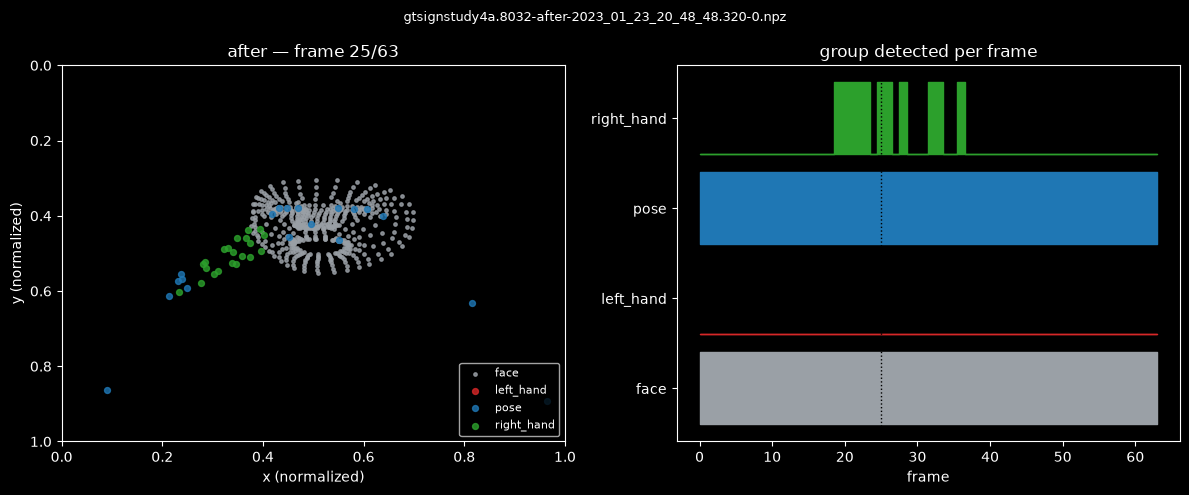

In [6]:
# =====
# 5. Visualize: one frame + group presence over time
# =====
PATH = SAMPLE
FRAME = None          # None = middle frame with both hands, else an int index
COLORS = {"face": "#9aa0a6", "pose": "#1f77b4",
          "left_hand": "#d62728", "right_hand": "#2ca02c"}

with np.load(PATH) as z:
    lm = z["landmarks"].astype(np.float32)

seen = {n: ~np.isnan(lm[:, lo:hi, 0]).all(axis=1) for n, (lo, hi) in GROUPS.items()}
if FRAME is None:
    cand = np.flatnonzero(seen["left_hand"] | seen["right_hand"])
    FRAME = int(cand[len(cand) // 2]) if len(cand) else len(lm) // 2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
for name, (lo, hi) in GROUPS.items():
    pts = lm[FRAME, lo:hi]
    ax1.scatter(pts[:, 0], pts[:, 1], s=6 if name == "face" else 18,
                c=COLORS[name], label=name, alpha=0.8)
ax1.set(xlim=(0, 1), ylim=(1, 0), xlabel="x (normalized)", ylabel="y (normalized)",
        title=f"{CLASS} — frame {FRAME}/{len(lm) - 1}")
ax1.legend(fontsize=8, loc="lower right")

for i, (name, s) in enumerate(seen.items()):
    ax2.fill_between(np.arange(len(s)), i, i + s * 0.8, color=COLORS[name], step="mid")
ax2.set(yticks=np.arange(len(seen)) + 0.4, yticklabels=list(seen),
        xlabel="frame", title="group detected per frame")
ax2.axvline(FRAME, color="k", ls=":", lw=1)
fig.suptitle(PATH.name, fontsize=9)
fig.tight_layout()
plt.show()

## 6. Loading idiom — npz → model input

How a downstream loader turns one of these files into the tensor the GISLR stack
expects: NaN → 0, optional landmark subset, uniform subsample to `MAX_SEQ_LEN`.
Mirrors `modules/model/data.py` so POPSIGN slots into the same training path.

In [7]:
# =====
# 6. Reference loader — npz to a (MAX_SEQ_LEN, L, C) array
# =====
PATH = SAMPLE
MAX_SEQ_LEN = 128      # same constant as modules/model/data.py
USE_XY_ONLY = True     # z is mostly noise for pose (see docs/logs/daily/2026-07-15.md)
SUBSET = None          # None = all 543 rows; else an index array, e.g. ME-126

def load_npz(path: Path, subset=None, xy_only=True, max_len=MAX_SEQ_LEN):
    with np.load(path) as z:
        seq = z["landmarks"].astype(np.float32)      # (T, 543, 3)
    if subset is not None:
        seq = seq[:, subset]
    if xy_only:
        seq = seq[..., :2]
    seq = np.nan_to_num(seq, nan=0.0)                # undetected -> 0
    if len(seq) != max_len and len(seq):             # uniform subsample / pad-by-repeat
        seq = seq[np.linspace(0, len(seq) - 1, max_len).round().astype(int)]
    return seq

x = load_npz(PATH, SUBSET, USE_XY_ONLY)
print(f"{PATH.name}\n  label (from folder): {PATH.parent.name}")
print(f"  model input: shape={x.shape} dtype={x.dtype} "
      f"range={x.min():.3f}..{x.max():.3f} zeros={np.mean(x == 0):.1%}")

gtsignstudy4a.8032-after-2023_01_23_20_48_48.320-0.npz
  label (from folder): after
  model input: shape=(128, 543, 2) dtype=float32 range=-0.074..2.012 zeros=7.1%
